# 02 — Обучение моделей

Ансамбль из трёх голов, каждая приходит к вероятностям исхода P(H/D/A) своим путём:

| Голова | Как получает вероятности | Роль |
|---|---|---|
| Dixon-Coles | распределение счетов → маргинализация | статистический baseline |
| ELO-логистика | обучаемая сигмоида на разнице рейтингов | быстрый baseline на 1 фиче |
| XGBoost | softmax на ~72 фичах | основная модель |

Дальше взвешенная комбинация и калибровка. Метрика оптимизации везде — **log_loss / Brier, не accuracy**: нам нужна честная вероятность.

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.football_model import (DixonColesModel, EloModel, XGBoostModel,
                                 build_feature_matrix, FEATURE_COLS)
plt.rcParams['figure.dpi'] = 110

features = pd.read_parquet('../data/processed/football_features.parquet')
raw_p1 = pd.read_parquet('../data/raw/football/matches_P1.parquet')
print('фичи:', features.shape, '| сырые P1:', raw_p1.shape)

фичи: (94043, 165) | сырые P1: (6511, 42)


## 1. Dixon-Coles — bivariate Poisson

Каждая команда имеет силу атаки и защиты. Ожидаемые голы: λ = exp(атака_хозяев − защита_гостей + дом.преимущество), μ симметрично. Голы моделируются как Пуассон, а поправка ρ чинит недооценку низких счетов и ничьих (0:0, 1:1).

In [2]:
dc = DixonColesModel(xi=0.002)
dc.fit(raw_p1)
print(f'home_adv={dc.home_adv_:.3f}  rho={dc.rho_:.3f}  (rho<0 поднимает ничьи)')
strengths = pd.DataFrame({'attack': dc.attack_, 'defence': dc.defence_}).sort_values('attack', ascending=False)
print('\nСильнейшие атаки Примейры:')
print(strengths.head(5).round(3).to_string())

home_adv=0.211  rho=0.015  (rho<0 поднимает ничьи)

Сильнейшие атаки Примейры:
           attack  defence
Sp Lisbon   0.789    0.572
Benfica     0.674    0.524
Porto       0.532    0.689
Sp Braga    0.515    0.205
Estoril     0.315   -0.216


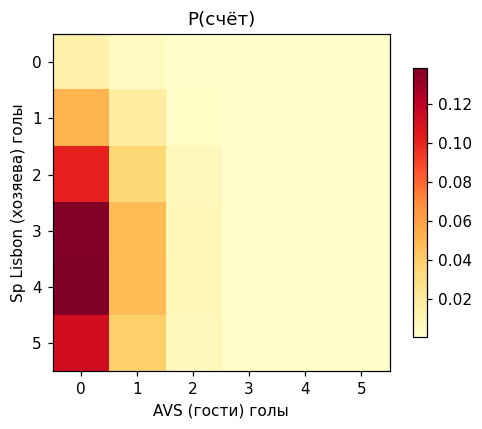

P(H)=0.95  P(D)=0.04  P(A)=0.01
P(H) = сумма нижнего треугольника, P(D) = диагональ, P(A) = верхний треугольник


In [3]:
# Матрица счетов для конкретной пары и маргинализация в исход
home, away = strengths.index[0], strengths.index[-1]
sm = dc.predict_score_matrix(home, away)[:6, :6]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sm, cmap='YlOrRd')
ax.set_xlabel(f'{away} (гости) голы'); ax.set_ylabel(f'{home} (хозяева) голы')
ax.set_title('P(счёт)'); plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

p = dc.predict_proba(home, away)
print(f'P(H)={p["home"]:.2f}  P(D)={p["draw"]:.2f}  P(A)={p["away"]:.2f}')
print('P(H) = сумма нижнего треугольника, P(D) = диагональ, P(A) = верхний треугольник')

## 2. ELO-логистика — обучаемая сигмоида

Классическая формула ELO использует жёсткий масштаб 400. Здесь логрегрессия **выучивает** наклон из данных: две one-vs-rest модели (победа хозяев / гостей), ничья как остаток.

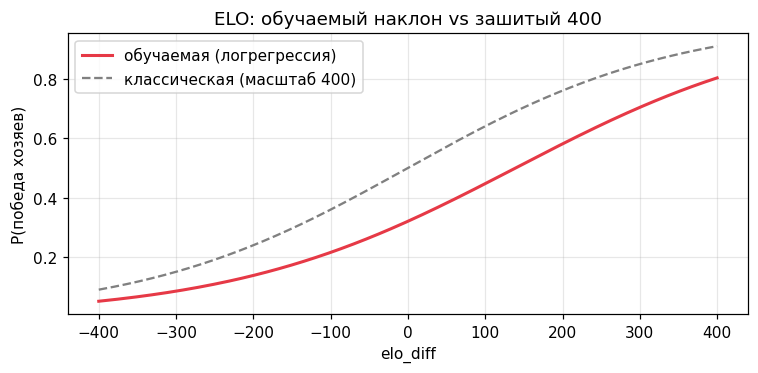

In [4]:
elo = EloModel()
elo.fit(features.dropna(subset=['elo_diff', 'target']))
grid = np.linspace(-400, 400, 200)
p_home_learned = [elo.predict_proba(d)['home'] for d in grid]
p_home_classic = 1 / (1 + 10 ** (-grid / 400))   # классическая ELO ожидаемость

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(grid, p_home_learned, label='обучаемая (логрегрессия)', color='#E63946', lw=2)
ax.plot(grid, p_home_classic, label='классическая (масштаб 400)', color='grey', ls='--')
ax.set_xlabel('elo_diff'); ax.set_ylabel('P(победа хозяев)')
ax.set_title('ELO: обучаемый наклон vs зашитый 400'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. XGBoost + Optuna

Гиперпараметры подбирает Optuna (TPE, 100 trials, objective = log_loss на временном val-сплите). Загружаем найденные параметры и смотрим их профиль.

In [5]:
with open('../data/results/xgboost_best_params.json') as f:
    best = json.load(f)
for k, v in best.items():
    print(f'  {k:18s} {v}')
print('\nПрофиль: мелкие деревья (max_depth), тяжёлая L1/L2 регуляризация,')
print('медленный learning_rate — консервативная модель под низкий signal-to-noise спорта.')

  n_estimators       475
  max_depth          3
  learning_rate      0.020381398581681535
  subsample          0.7128160230382746
  colsample_bytree   0.6068266551535485
  min_child_weight   9
  reg_alpha          0.7917547667818363
  reg_lambda         1.304001938894021

Профиль: мелкие деревья (max_depth), тяжёлая L1/L2 регуляризация,
медленный learning_rate — консервативная модель под низкий signal-to-noise спорта.


In [6]:
# короткий демо-прогон Optuna (15 trials) на подвыборке, чтобы показать механику
# полный прогон (100 trials, все лиги) делается overnight_pipeline.py на сервере
try:
    import optuna
    from xgboost import XGBClassifier
    from sklearn.metrics import log_loss
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    sub = features[features.League.isin(['E0', 'D1'])].copy()
    seasons = sorted(sub.Season.astype(str).unique())
    tr = sub[sub.Season.astype(str).isin(seasons[:-2])]
    va = sub[sub.Season.astype(str).isin(seasons[-2:])]
    Xtr, ytr, _ = build_feature_matrix(tr)
    Xva, yva, _ = build_feature_matrix(va)

    def obj(t):
        clf = XGBClassifier(
            n_estimators=t.suggest_int('n_estimators', 200, 600),
            max_depth=t.suggest_int('max_depth', 3, 6),
            learning_rate=t.suggest_float('learning_rate', 0.01, 0.15, log=True),
            objective='multi:softprob', num_class=3, eval_metric='mlogloss',
            random_state=42, n_jobs=-1)
        clf.fit(Xtr, ytr, verbose=False)
        return log_loss(yva, clf.predict_proba(Xva))

    study = optuna.create_study(direction='minimize')
    study.optimize(obj, n_trials=15, show_progress_bar=False)
    print(f'демо best log_loss={study.best_value:.4f}, лучшие: {study.best_params}')
except ImportError:
    print('optuna не установлен, пропускаем демо (полные параметры уже загружены выше)')

демо best log_loss=0.9835, лучшие: {'n_estimators': 340, 'max_depth': 4, 'learning_rate': 0.010182346652647013}


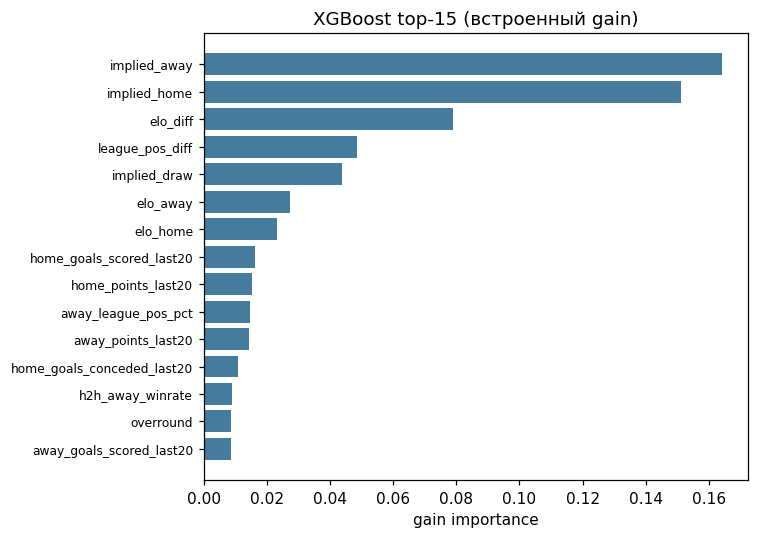

In [7]:
# Обучаем XGBoost на всех данных с найденными параметрами, смотрим gain-важность
X, y, cols = build_feature_matrix(features)
xgb = XGBoostModel(**best)
xgb.fit(X, y, cols)
imp = xgb.feature_importance().head(15)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(range(len(imp))[::-1], imp.values, color='#457B9D')
ax.set_yticks(range(len(imp))[::-1]); ax.set_yticklabels(imp.index, fontsize=8)
ax.set_xlabel('gain importance'); ax.set_title('XGBoost top-15 (встроенный gain)')
plt.tight_layout(); plt.show()

## 4. Веса ансамбля — честная находка

Веса подбираются Optuna по Brier. Смотрим результат.

In [8]:
with open('../data/results/ensemble_best_weights.json') as f:
    w = json.load(f)
for k, v in w.items():
    print(f'  {k:12s} {v:.6f}')
print('\nDixon-Coles и ELO занулены, всё тянет XGBoost. Это не провал, а вывод:')
print('elo_diff уже топ-фича внутри XGBoost, а draw-фичи поглощают то, что моделирует rho.')
print('Классические головы служат sanity-check baseline, который бустинг обязан обойти.')

  dixon_coles  0.000005
  elo          0.000008
  xgboost      0.999987

Dixon-Coles и ELO занулены, всё тянет XGBoost. Это не провал, а вывод:
elo_diff уже топ-фича внутри XGBoost, а draw-фичи поглощают то, что моделирует rho.
Классические головы служат sanity-check baseline, который бустинг обязан обойти.


## 5. SHAP — объяснение через теорию игр

Встроенный gain смещён к непрерывным признакам. SHAP (значения Шепли) даёт несмещённую атрибуцию и локальные объяснения. TreeSHAP считает это точно и быстро на деревьях.

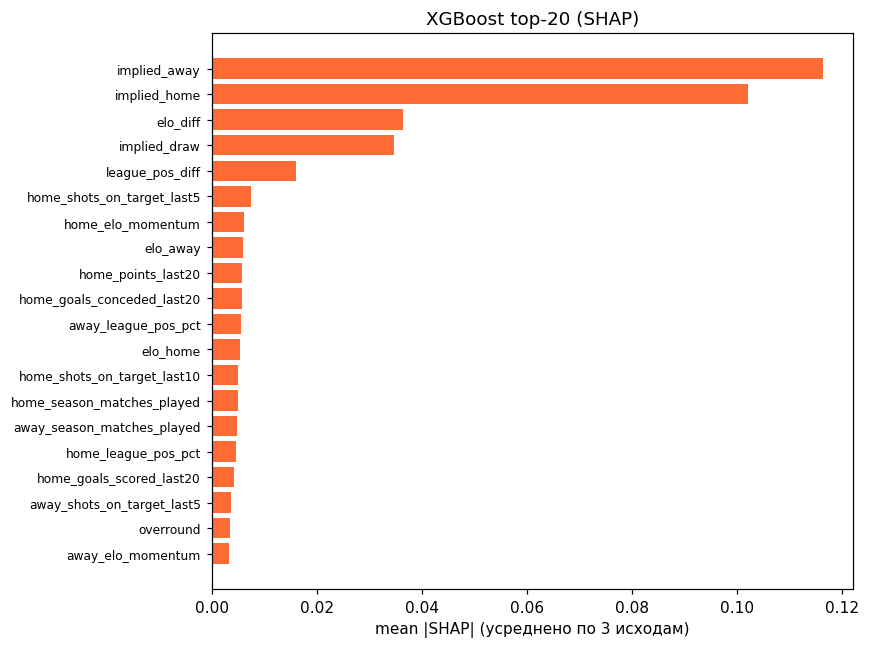

In [9]:
import shap
n = min(2000, len(X))
idx = np.random.RandomState(42).choice(len(X), n, replace=False)
Xs = X[idx]
explainer = shap.TreeExplainer(xgb.clf)
sv = explainer.shap_values(Xs)
# усредняем |SHAP| по трём классам (форматы shap отличаются между версиями)
if isinstance(sv, list):
    mean_abs = np.mean([np.abs(s).mean(0) for s in sv], axis=0)
else:
    mean_abs = np.abs(sv).mean(axis=(0, 2))

top = np.argsort(mean_abs)[-20:]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(20), mean_abs[top], color='#FF6B35')
ax.set_yticks(range(20)); ax.set_yticklabels([cols[i] for i in top], fontsize=8)
ax.set_xlabel('mean |SHAP| (усреднено по 3 исходам)')
ax.set_title('XGBoost top-20 (SHAP)')
plt.tight_layout(); plt.show()

## Итог

- Три головы дают P(H/D/A) разными путями; Optuna зануляет DC и ELO — их сигнал уже внутри XGBoost.
- XGBoost настроен консервативно (мелкие деревья, сильная регуляризация) под шумные спортивные данные.
- gain и SHAP согласуются по топовым фичам; SHAP несмещён и объясняет конкретные предсказания.

Дальше: **03_probability_calibration** — насколько вероятности честны и как калибровка это чинит.